In [2]:
import pandas as pd
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load GSS dataset
df_cs_abo = pd.read_csv('data/GSS/gss_abt_cs_abortion.csv')
df_cs_homosex = pd.read_csv('data/GSS/gss_abt_cs_homosex.csv')
df_pl_abo = pd.read_csv('data/GSS/gss_abt_panel_abortion.csv')
df_pl_homosex = pd.read_csv('data/GSS/gss_abt_panel_homosex.csv')

In [5]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 12), (12610, 11), (17576, 12), (13647, 11))

In [6]:
# Convert year 2021 to 2020
df_cs_abo.loc[df_cs_abo['year'] == 2021, 'year'] = 2020
df_cs_homosex.loc[df_cs_homosex['year'] == 2021, 'year'] = 2020
df_pl_abo.loc[df_pl_abo['year'] == 2021, 'year'] = 2020
df_pl_homosex.loc[df_pl_homosex['year'] == 2021, 'year'] = 2020

In [ ]:
ABORT4 = ["strong_anti", "anti", "pro", "strong_pro"]
HOMOSEX4 = ["always_wrong", "almost_always_wrong", "sometimes_wrong", "not_wrong_at_all"]

GROUP_COLS_4 = ["generation","gender","race","edu_level"]
GROUP_COLS_3 = ["generation","gender","race"]
GROUP_COLS_2 = ["generation","gender"]
GROUP_COLS_1 = ["generation"]

ABORT2ID = {c:i for i,c in enumerate(ABORT4)}
HOMOSEX2ID = {c:i for i,c in enumerate(HOMOSEX4)}

In [8]:
# Multinomial logistic AR analysis
from sklearn.linear_model import Ridge

# ALR helpers (reference = last category)
def alr(p, eps=1e-8):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0)
    p = p / p.sum()
    ref = p[-1]
    return np.log(p[:-1] / ref)

def inv_alr(u):
    u = np.asarray(u, dtype=float)
    z = np.r_[np.exp(u), 1.0]
    return z / z.sum()

# Fit AR(1) per subgroup with ridge, forecast next year
def cs_ar_fit_and_forecast(p_cs, l2=1.0, min_years=3):
    """
    p_cs: dict {((group_tuple), year) -> p (K,)}
    Returns dict {((group_tuple), year_next) -> p_hat_AR}
    """
    by_group = {}
    for (g,y), p in p_cs.items():
        by_group.setdefault(g, []).append(int(y))

    forecasts = {}
    for g, ys in by_group.items():
        ys = sorted(ys)
        if len(ys) < min_years:
            # too few years: fallback to persistence p_{t+1} = p_t
            for i in range(1, len(ys)):
                y_prev, y = ys[i-1], ys[i]
                forecasts[(g, y)] = p_cs[(g, y_prev)]
            continue

        # Build (X=u_{t-1}, Y=u_t) in ALR space
        X_list, Y_list, targets = [], [], []
        for i in range(1, len(ys)):
            y_prev, y = ys[i-1], ys[i]
            u_prev = alr(p_cs[(g, y_prev)])
            u_curr = alr(p_cs[(g, y)])
            X_list.append(np.r_[1.0, u_prev])   # intercept + u_{t-1}
            Y_list.append(u_curr)
            targets.append((g, y))
        X = np.vstack(X_list)        # [T-1, 1+(K-1)]
        Y = np.vstack(Y_list)        # [T-1, (K-1)]

        # Fit separate Ridge for each ALR dimension (small T)
        coefs = []
        for k in range(Y.shape[1]):
            reg = Ridge(alpha=l2, fit_intercept=False)  # intercept already in X
            reg.fit(X, Y[:,k])
            coefs.append(reg.coef_)
        B = np.vstack(coefs)  # shape [(K-1) x (K)]

        # Forecast each step from previous observed (one-step ahead backtest)
        for i in range(1, len(ys)):
            y_prev, y = ys[i-1], ys[i]
            u_prev = alr(p_cs[(g, y_prev)])
            x = np.r_[1.0, u_prev]             # [K]
            u_hat = B @ x                      # [K-1]
            p_hat = inv_alr(u_hat)
            forecasts[(g, y)] = p_hat

    return forecasts

In [9]:
# Markov model
def row_normalize(M, alpha=0.25):
    M = np.asarray(M, dtype=float)
    M = M + alpha
    rs = M.sum(axis=1, keepdims=True)
    return M / np.clip(rs, 1e-12, None)

def panel_markov_forecast(p_cs, C, Nfrom, alpha=0.25):
    """
    p_cs: {((g), y) -> p}
    C, Nfrom: panel counts keyed by ((g_tuple), t, Δ)
    Returns dict {((g), y) -> p_hat_MC} for years that have (g, y-Δ) and panel info.
    """
    forecasts = {}
    # Build a lookup of T per (g, Δ, anchor t) and also a pooled (g, Δ) if you want to pool across t
    T_lookup = {}
    for key, mat in C.items():
        g, t, Δ = key
        T = row_normalize(mat, alpha=alpha)
        T_lookup[(g, t, Δ)] = T


    # Option: pooled T over t for a given (g, Δ) to improve stability
    pooled_T = {}
    for (g,t,Δ), T in T_lookup.items():
        pooled_T.setdefault((g, Δ), []).append(T)
    pooled_T = {k: np.mean(v, axis=0) for k,v in pooled_T.items()}

    # Forecast wherever possible
    by_group = {}
    for (g,y), _ in p_cs.items():
        by_group.setdefault(g, []).append(int(y))
    for g, ys in by_group.items():
        ys = sorted(ys)
        for i in range(1, len(ys)):
            y_prev, y = ys[i-1], ys[i]
            Δ = y - y_prev
            p_prev = p_cs[(g, y_prev)]
            # prefer anchored T at (g, t=y_prev), else pooled over t for (g, Δ)
            T = T_lookup.get((g, y_prev, Δ))
            if T is None:
                T = pooled_T.get((g, Δ))
            if T is None:
                continue  # no panel info for this gap
            p_hat = p_prev @ T
            p_hat = p_hat / np.clip(p_hat.sum(), 1e-12, None)
            forecasts[(g, y)] = p_hat
    return forecasts

In [12]:
# Find p_cs and Nfrom
cs = df_cs_abo.copy()
# Map to 4 bins if numeric:
cs = cs[cs["abortion_att4"].isin(ABORT4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_4
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=ABORT4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in ABORT4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs = {}
effN_cs = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_4):
        p = weighted_probs(df_g["abortion_att4"].tolist(), df_g["wt"].tolist(), ABORT4)
        if p is None:
            continue
        p_cs[(g_vals, y)] = p
        effN_cs[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return ABORT2ID.get(cat, None)

C = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_abo["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id in df_pl_abo.groupby("yearid"):
    df_id = df_id.sort_values("year")
    # collapse duplicates per year if any
    df_id = df_id.drop_duplicates(subset=["year"], keep="last")
    years = df_id["year"].values.tolist()
    atts  = df_id["abortion_att4"].values.tolist()
    wgts  = df_id["w"].values.astype(float).tolist()
    gens  = df_id["generation"].values.tolist()
    gend  = df_id["gender"].values.tolist()
    race  = df_id["race"].values.tolist()
    edu = df_id["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1 and len(set(gend))==1 and len(set(race))==1 and len(set(edu))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0], gend[0], race[0], edu[0])
    
    # Abortion (K=4)
    K = len(ABORT4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C[(g,t,Δ)][ai, aj] += w
        Nfrom[(g,t,Δ)][ai] += w

In [13]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR = cs_ar_fit_and_forecast(p_cs, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC = panel_markov_forecast(p_cs, C, Nfrom, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_4, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs[(g, y)]
        if (g, y) in p_hat_AR:
            rec["JSD_AR"] = float(jsd(p_hat_AR[(g,y)], p_obs))
        if (g, y) in p_hat_MC:
            rec["JSD_MC"] = float(jsd(p_hat_MC[(g,y)], p_obs))
        rows.append(rec)

bench = pd.DataFrame(rows)
bench.head()


,generation,gender,race,edu_level,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.028272,0.346626
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.357902,0.064341
2,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2010,2012,0.398768,0.229432
3,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2012,2014,0.102151,0.196799
4,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2014,2016,0.117836,0.055920


In [27]:
bench.shape, df_bt.shape

((675, 8), (414, 10))

In [28]:
# Load backtest results from LLM experiments
df_bt = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_abortion_g4.csv")

# Merge df_bt to benchmark DataFrame
df_bt = df_bt.merge(bench, on=GROUP_COLS_4 + ["year_t", "year_t1"], how="left")
df_bt.shape

(414, 12)

In [31]:
bench.head()

,generation,gender,race,edu_level,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.028272,0.346626
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.357902,0.064341
2,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2010,2012,0.398768,0.229432
3,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2012,2014,0.102151,0.196799
4,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2014,2016,0.117836,0.055920


In [33]:
df_bt['year_t'].value_counts()

year_t
2022    90
2016    71
2014    69
2012    63
2010    61
2008    60
Name: count, dtype: int64

In [38]:
df_bt.head(1)

,year_t,year_t1,generation,gender,race,edu_level,JSD_hat,JSD_trans,JSD_margin,RMSE_hat,JSD_AR,JSD_MC
0,2008,2010,Baby Boomer,Female,Black,Associate or Bachelor's Degree,0.0667,0.04372,0.131728,0.176592,0.357902,0.064341


In [39]:
df_pred.head(2)

,generation,gender,race,edu_level,year_prev,year,p_prev_strong_anti,p_prev_anti,p_prev_pro,p_prev_strong_pro,...,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.156398,0.409694,0.208237,0.225671,...,0.0,0.079963,0.000000,0.920037,0.099381,0.176772,0.248766,0.004162,2006,2008
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.000000,0.079963,0.000000,0.920037,...,0.0,0.209616,0.266931,0.523453,0.066700,0.176592,0.043720,0.131728,2008,2010


In [34]:
df_bt.groupby(['generation','gender','race','edu_level']).size()

generation         gender  race   edu_level                     
Baby Boomer        Female  Black  Associate or Bachelor's Degree    6
                                  Graduate Degree                   6
                                  Less or equal to high school      6
                           Other  Associate or Bachelor's Degree    6
                                  Graduate Degree                   5
                                                                   ..
Silent Generation  Male    Other  Graduate Degree                   2
                                  Less or equal to high school      5
                           White  Associate or Bachelor's Degree    6
                                  Graduate Degree                   6
                                  Less or equal to high school      6
Length: 85, dtype: int64

In [36]:
df_pred.head()

,generation,gender,race,edu_level,year_prev,year,p_prev_strong_anti,p_prev_anti,p_prev_pro,p_prev_strong_pro,...,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.156398,0.409694,0.208237,0.225671,...,0.000000,0.079963,0.000000,0.920037,0.099381,0.176772,0.248766,0.004162,2006,2008
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.000000,0.079963,0.000000,0.920037,...,0.000000,0.209616,0.266931,0.523453,0.066700,0.176592,0.043720,0.131728,2008,2010
2,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2010,2012,0.000000,0.209616,0.266931,0.523453,...,0.000000,0.000000,0.931083,0.068917,0.399667,0.531282,0.305896,0.563040,2010,2012
3,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2012,2014,0.000000,0.000000,0.931083,0.068917,...,0.170761,0.104417,0.000000,0.724822,0.193566,0.285121,0.148665,0.261511,2012,2014
4,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2014,2016,0.170761,0.104417,0.000000,0.724822,...,0.197131,0.030886,0.404403,0.367580,0.028078,0.104322,0.067667,0.209976,2014,2016


In [14]:
# Load our predicted values (p-hat)
df_pred = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_abortion_g4.csv")

# Convert year 2021 to 2020
df_pred.loc[df_pred['year'] == 2021, 'year'] = 2020
df_pred.loc[df_pred['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred['year_t'] = df_pred['year_prev']
df_pred['year_t1'] = df_pred['year']

df_pred.head(2)

,generation,gender,race,edu_level,year_prev,year,p_prev_strong_anti,p_prev_anti,p_prev_pro,p_prev_strong_pro,...,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2006,2008,0.156398,0.409694,0.208237,0.225671,...,0.0,0.079963,0.000000,0.920037,0.099381,0.176772,0.248766,0.004162,2006,2008
1,Baby Boomer,Female,Black,Associate or Bachelor's Degree,2008,2010,0.000000,0.079963,0.000000,0.920037,...,0.0,0.209616,0.266931,0.523453,0.066700,0.176592,0.043720,0.131728,2008,2010


In [ ]:
# # Build p_hat from df_pred
# def get_group_cols(group=GROUP_COLS_4):
#     return group

# def list_groups_sorted_by_coverage(p_cs, min_years=3):
#     counts = {}
#     for (g, y) in p_cs.keys():
#         counts.setdefault(g, set()).add(y)
#     items = sorted(((g, len(ys)) for g, ys in counts.items()),
#                    key=lambda x: x[1], reverse=True)
#     return [g for g, n in items if n >= min_years]

# def _extract_bt_series_for_group(bt, g, series="hat"):
#     """
#     bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
#     g: tuple of group values in get_group_cols() order
#     series: 'hat', 'margin', or 'trans'
#     Returns dict year -> np.array(K)
#     """
#     if bt is None:
#         return {}
#     # Filter to rows for this group
#     mask = np.ones(len(bt), dtype=bool)
#     for c, v in zip(get_group_cols(), g):
#         mask &= (bt[c] == v)
#     sub = bt.loc[mask].copy()
#     if sub.empty:
#         return {}

#     # Predictions are for year_t1
#     year_col = "year_t1"
#     out = {}
#     for _, row in sub.iterrows():
#         vec = []
#         for cat in ABORT4:
#             col = f"p_{series}_{cat}"
#             if col not in sub.columns:
#                 # If you saved only ensemble 'hat', default others to None
#                 return {}
#             vec.append(row[col])
#         vec = np.asarray(vec, dtype=float)
#         y = int(row[year_col])
#         out[y] = vec
#     return out

# def build_group_timeseries_with_tllm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, tllm_series=("hat",)):
#     """
#     Build tidy DF with columns: year, category, observed, ar, tllm_hat, tllm_margin, tllm_trans (as available).
#     """
#     years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
#     # Collect T-LLM series
#     t_series = {}
#     for s in tllm_series:
#         t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

#     rows = []
#     for y in years:
#         p_obs = p_cs.get((g, y))
#         p_ar  = p_hat_AR.get((g, y))
#         p_mc  = p_hat_MC.get((g, y))
#         for k, cat in enumerate(ABORT4):
#             rec = {
#                 "year": y,
#                 "category": cat,
#                 "observed": float(p_obs[k]) if p_obs is not None else np.nan,
#                 "ar": float(p_ar[k]) if p_ar is not None else np.nan,
#                 "mc": float(p_mc[k]) if p_mc is not None else np.nan
#             }
#             for s in tllm_series:
#                 vecs = t_series.get(s, {})
#                 rec[f"tllm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
#             rows.append(rec)
#     return pd.DataFrame(rows)

# def plot_vs_observed_for_group_with_tllm(
#     g, p_cs, p_hat_AR, p_hat_MC, bt=None, tllm_series=("hat",), save_path=None
# ):
#     """
#     4-panel plot (one per category): Observed vs AR vs MC vs T-LLM.
#     tllm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
#     """
#     df = build_group_timeseries_with_tllm(g, p_cs, p_hat_AR, p_hat_MC, bt, tllm_series=tllm_series)
#     if df.empty:
#         print("No data for that group.")
#         return

#     years = sorted(df["year"].unique())
#     fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
#     axes = axes.ravel()

#     group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
#     fig.suptitle(f"Observed vs AR vs MC vs T-LLM — {group_label}", y=1.02, fontsize=12)

#     for i, cat in enumerate(CANON4):
#         ax = axes[i]
#         d = df[df["category"] == cat].sort_values("year")

#         ax.plot(d["year"], d["observed"], marker="o", linestyle="-", label="Observed")
#         ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
#         ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

#         # Add T-LLM lines
#         color_cycle_added = False
#         for s in tllm_series:
#             ax.plot(d["year"], d[f"tllm_{s}"], marker="^", linestyle=":",
#                     label=f"LLM {s}")

#         ax.set_title(cat)
#         ax.set_xticks(range(2006,2026,2))
#         ax.grid(alpha=0.3)
#         if i % 2 == 0:
#             ax.set_ylabel("Proportion")
#         if i // 2 == 1:
#             ax.set_xlabel("Year")

#     handles, labels = axes[0].get_legend_handles_labels()
#     # deduplicate legend entries
#     seen = set(); h2, l2 = [], []
#     for h, l in zip(handles, labels):
#         if l not in seen:
#             seen.add(l); h2.append(h); l2.append(l)
#     fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(tllm_series)), bbox_to_anchor=(0.5, -0.02))
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=200, bbox_inches="tight")
#         print("Saved:", save_path)
#     plt.show()

# # candidates = list_groups_sorted_by_coverage(p_cs, min_years=3)
# # g_example = candidates[0] if candidates else next(iter({g for (g,_) in p_cs}))
# # Show ensemble 'hat' only:
# CANON4 = ABORT4
# g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
# plot_vs_observed_for_group_with_tllm(g, p_cs, p_hat_AR, p_hat_MC, bt=df_pred, tllm_series=("hat",))

In [23]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = ABORT4

def get_group_cols(group=GROUP_COLS_4):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":", color="#e14b31",
                    label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle="--", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

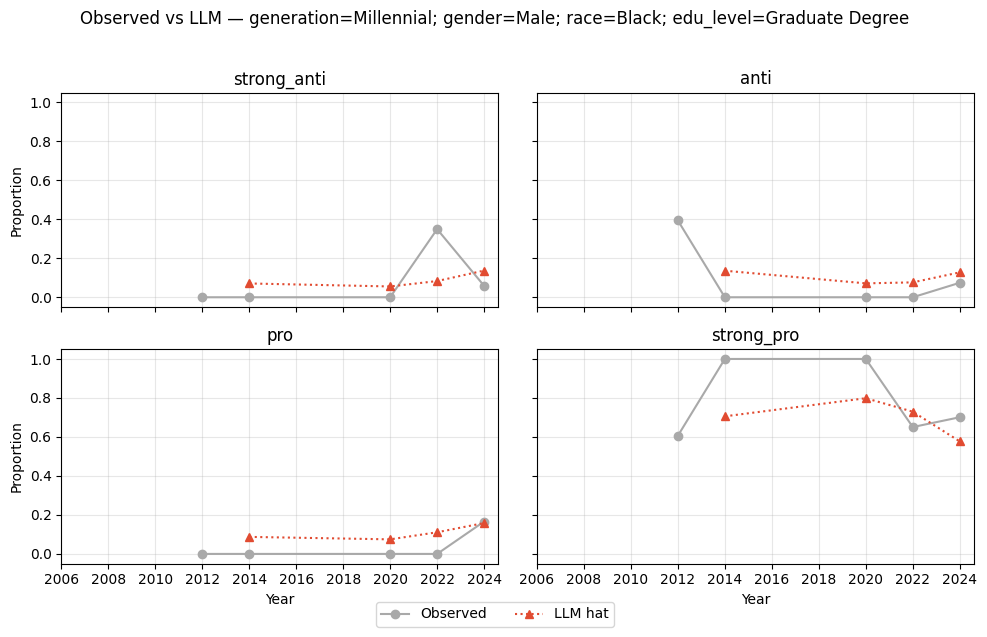

In [62]:
g = ('Millennial', 'Male', 'Black', "Graduate Degree")
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=df_pred, llm_series=("hat",))

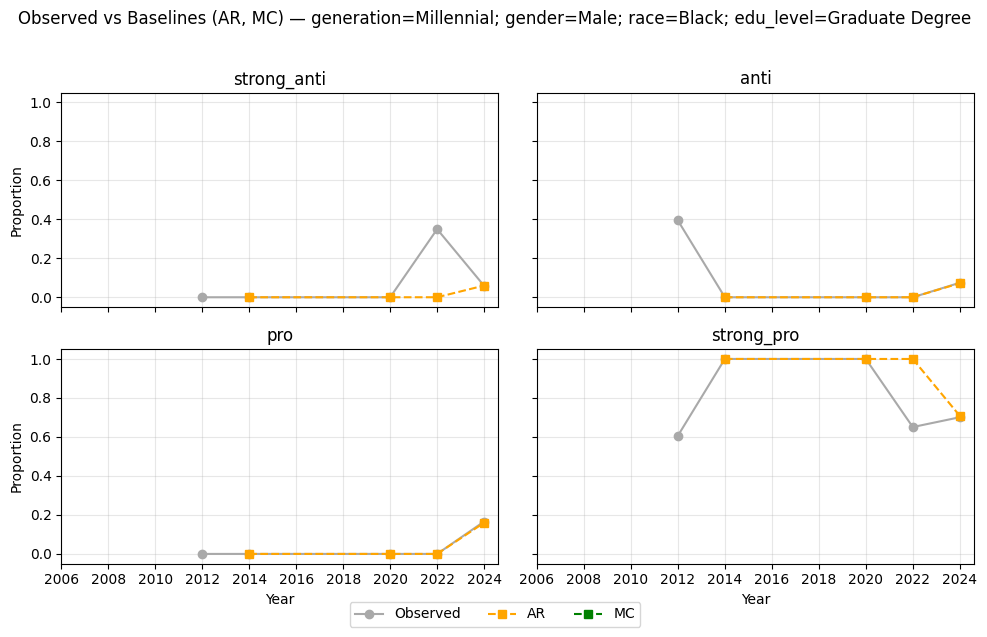

In [63]:
g = ('Millennial', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_baselines(g, p_cs, p_hat_AR, p_hat_MC, bt=df_pred, llm_series=("hat",))

In [46]:
a = {v:i for i, v in enumerate(ABORT4)}
df_cs_abo['abortion_int4'] = df_cs_abo['abortion_att4'].map(a)

In [58]:
# Calculate weighted means and standard errors
df_cs_abo.groupby(['generation','edu_level','gender','race']).agg(
    wtssps_mean=('wtssps', 'mean'),
    wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index().sort_values('wtssps_se', ascending=False).head(10)

,generation,edu_level,gender,race,wtssps_mean,wtssps_se
42,Generation Z,Associate or Bachelor's Degree,Male,Other,1.923226,1.372107
45,Generation Z,Graduate Degree,Female,Other,0.732209,0.529142
85,Silent Generation,Graduate Degree,Male,Black,1.645595,0.472436
83,Silent Generation,Graduate Degree,Female,Other,1.133605,0.438481
38,Generation Z,Associate or Bachelor's Degree,Female,Black,0.988419,0.433524
80,Silent Generation,Associate or Bachelor's Degree,Male,Other,1.174328,0.407938
39,Generation Z,Associate or Bachelor's Degree,Female,Other,0.843658,0.323392
66,Millennial,Graduate Degree,Male,Black,1.125565,0.318219
53,Generation Z,Less or equal to high school,Male,Other,2.008937,0.312843
86,Silent Generation,Graduate Degree,Male,Other,1.703957,0.279423


In [47]:
df_cs_abo.head()

,yearid,year,generation,edu_level,gender,race,political_views,natenvir,trust,abortion_att4,homosex,wtssps,abortion_int4
0,2006_4,2006,Baby Boomer,Less or equal to high school,Female,Black,Liberal,NaN,depends,strong_pro,not_wrong_at_all,0.385372,3
1,2006_5,2006,Millennial,Less or equal to high school,Male,Black,Liberal,NaN,distrust,strong_pro,always_wrong,1.387133,3
2,2006_9,2006,Millennial,Associate or Bachelor's Degree,Female,Black,Conservative,NaN,distrust,strong_pro,NaN,0.421749,3
3,2006_10,2006,Generation X,Graduate Degree,Female,Other,Liberal,too_little,NaN,strong_pro,always_wrong,0.527395,3
4,2006_12,2006,Baby Boomer,Less or equal to high school,Male,Black,Moderate,NaN,distrust,strong_anti,NaN,2.423198,0


## Group 1

In [64]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 13), (12610, 12), (17576, 12), (13647, 11))

In [65]:
df_cs_abo.head()

,yearid,year,generation,edu_level,gender,race,political_views,natenvir,trust,abortion_att4,homosex,wtssps,abortion_int4
0,2006_4,2006,Baby Boomer,Less or equal to high school,Female,Black,Liberal,NaN,depends,strong_pro,not_wrong_at_all,0.385372,3
1,2006_5,2006,Millennial,Less or equal to high school,Male,Black,Liberal,NaN,distrust,strong_pro,always_wrong,1.387133,3
2,2006_9,2006,Millennial,Associate or Bachelor's Degree,Female,Black,Conservative,NaN,distrust,strong_pro,NaN,0.421749,3
3,2006_10,2006,Generation X,Graduate Degree,Female,Other,Liberal,too_little,NaN,strong_pro,always_wrong,0.527395,3
4,2006_12,2006,Baby Boomer,Less or equal to high school,Male,Black,Moderate,NaN,distrust,strong_anti,NaN,2.423198,0


In [80]:
# Find p_cs and Nfrom
cs = df_cs_abo.copy()
# Map to 4 bins if numeric:
cs = cs[cs["abortion_att4"].isin(ABORT4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_1
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=ABORT4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in ABORT4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs_g1 = {}
effN_cs_g1 = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_1):
        p = weighted_probs(df_g["abortion_att4"].tolist(), df_g["wt"].tolist(), ABORT4)
        if p is None:
            continue
        p_cs_g1[(g_vals, y)] = p
        effN_cs_g1[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return ABORT2ID.get(cat, None)

C_g1 = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom_g1 = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_abo["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id_g1 in df_pl_abo.groupby("yearid"):
    df_id_g1 = df_id_g1.sort_values("year")
    # collapse duplicates per year if any
    df_id_g1 = df_id_g1.drop_duplicates(subset=["year"], keep="last")
    years = df_id_g1["year"].values.tolist()
    atts  = df_id_g1["abortion_att4"].values.tolist()
    wgts  = df_id_g1["w"].values.astype(float).tolist()
    gens  = df_id_g1["generation"].values.tolist()
    # gend  = df_id_g1["gender"].values.tolist()
    # race  = df_id_g1["race"].values.tolist()
    # edu = df_id_g1["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0],)
    
    # Abortion (K=4)
    K = len(ABORT4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C_g1[(g,t,Δ)][ai, aj] += w
        Nfrom_g1[(g,t,Δ)][ai] += w

In [82]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR_g1 = cs_ar_fit_and_forecast(p_cs_g1, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC_g1 = panel_markov_forecast(p_cs_g1, C_g1, Nfrom_g1, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs_g1.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_1, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs_g1[(g, y)]
        if (g, y) in p_hat_AR_g1:
            rec["JSD_AR"] = float(jsd(p_hat_AR_g1[(g,y)], p_obs))
        if (g, y) in p_hat_MC_g1:
            rec["JSD_MC"] = float(jsd(p_hat_MC_g1[(g,y)], p_obs))
        rows.append(rec)

bench = pd.DataFrame(rows)
bench.head()


,generation,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,2006,2008,0.000808,0.000639
1,Baby Boomer,2008,2010,0.000891,0.002087
2,Baby Boomer,2010,2012,0.000063,0.001314
3,Baby Boomer,2012,2014,0.000534,0.000829
4,Baby Boomer,2014,2016,0.000977,0.002596


In [88]:
# Load our predicted values (p-hat)
df_pred_g1 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_abortion_g1.csv")

# Convert year 2021 to 2020
df_pred_g1.loc[df_pred_g1['year'] == 2021, 'year'] = 2020
df_pred_g1.loc[df_pred_g1['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred_g1['year_t'] = df_pred_g1['year_prev']
df_pred_g1['year_t1'] = df_pred_g1['year']

gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
df_pred_g1['generation'] = df_pred_g1['generation'].map(gen_map)

df_pred_g1.head(2)

,generation,year_prev,year,p_prev_strong_anti,p_prev_anti,p_prev_pro,p_prev_strong_pro,p_trans_strong_anti,p_trans_anti,p_trans_pro,...,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,2006,2008,0.169826,0.308336,0.133590,0.388247,0.175976,0.287115,0.149187,...,0.157098,0.290347,0.153132,0.399422,0.000036,0.004284,0.000329,0.000303,2006,2008
1,Baby Boomer,2008,2010,0.157098,0.290347,0.153132,0.399422,0.164061,0.288862,0.144214,...,0.194740,0.240697,0.174067,0.390495,0.001717,0.028323,0.002503,0.001648,2008,2010


In [114]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = ABORT4

def get_group_cols(group=GROUP_COLS_1):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle="-", color="#e14b31",
                    label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle=":", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle=":", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

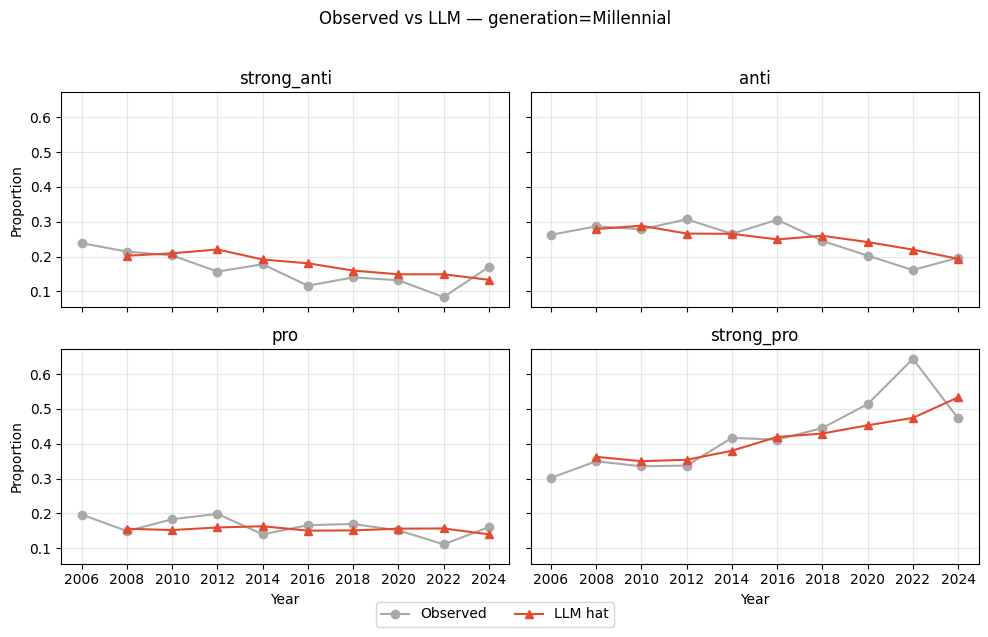

In [115]:
g = ('Millennial',)
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g1, p_hat_AR_g1, p_hat_MC_g1, bt=df_pred_g1, llm_series=("hat",))

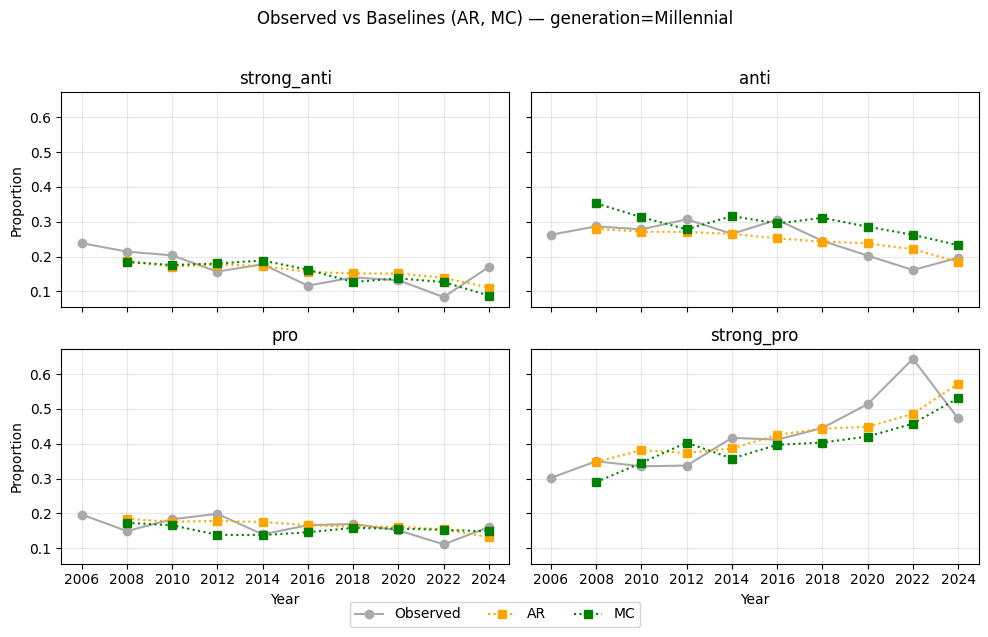

In [116]:
plot_vs_observed_for_group_with_baselines(g, p_cs_g1, p_hat_AR_g1, p_hat_MC_g1, bt=df_pred_g1, llm_series=("hat",))

In [93]:
# Calculate weighted means and standard errors for G1
df_cs_abo.groupby(['generation']).agg(
    wtssps_mean=('wtssps', 'mean'),
    wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index().sort_values('wtssps_se', ascending=False).head(10)

,generation,wtssps_mean,wtssps_se
2,Generation Z,1.488945,0.072510
3,Millennial,1.138935,0.016572
4,Silent Generation,0.906270,0.014591
1,Generation X,0.978666,0.012092
0,Baby Boomer,0.906313,0.009878


In [100]:
# Compare JSD
bt_abo_g1 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_abortion_g1.csv")

gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
bt_abo_g1['generation'] = bt_abo_g1['generation'].map(gen_map)

bt_abo_g1.head()

,year_t,year_t1,generation,JSD_hat,JSD_trans,JSD_margin,RMSE_hat
0,2008,2010,Baby Boomer,0.001717,0.002503,0.001648,0.028323
1,2008,2010,Generation X,0.001471,0.002132,0.002022,0.026618
2,2008,2010,Millennial,0.000861,0.002334,0.000220,0.018123
3,2008,2010,Silent Generation,0.018818,0.019295,0.018799,0.092099
4,2010,2012,Baby Boomer,0.000085,0.001141,0.001772,0.006477


In [106]:
# Convert bench to long format
bench_long = pd.melt(bench, id_vars=GROUP_COLS_1 + ['year_t', 'year_t1'], value_vars=['JSD_AR', 'JSD_MC'], var_name='model', value_name='jsd')
model_map = {'JSD_AR': 'AR', 'JSD_MC': 'MC'}
bench_long['model'] = bench_long['model'].map(model_map)

# Prepare the data for plotting
bt_abo_g1['model'] = 'LLM'
bt_abo_g1 = bt_abo_g1.rename(columns={'JSD_hat':'jsd'})
combined_g1 = pd.concat([bench_long, bt_abo_g1[['generation','year_t','year_t1','model','jsd']]], ignore_index=True)
combined_g1.head()

,generation,year_t,year_t1,model,jsd
0,Baby Boomer,2006,2008,AR,0.000808
1,Baby Boomer,2008,2010,AR,0.000891
2,Baby Boomer,2010,2012,AR,0.000063
3,Baby Boomer,2012,2014,AR,0.000534
4,Baby Boomer,2014,2016,AR,0.000977


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/937476771.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


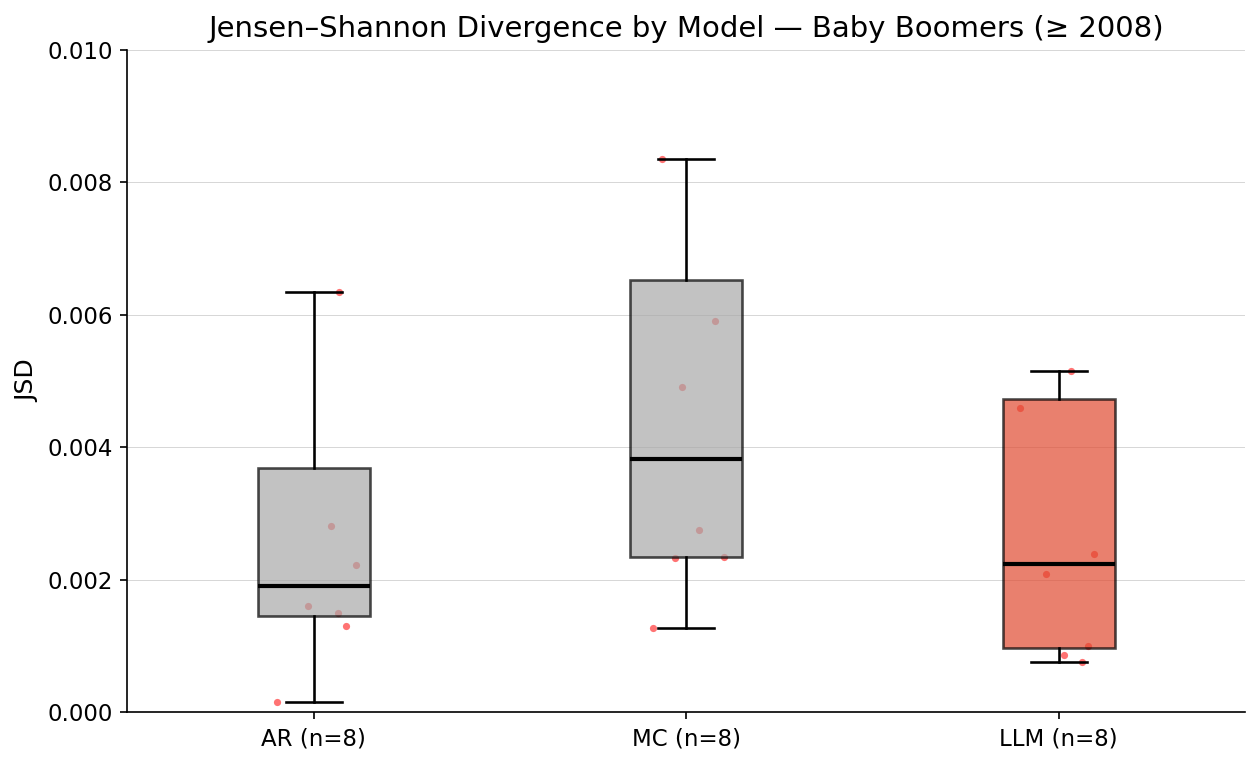

In [129]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g1[(combined_g1['generation'] == 'Millennial') & (combined_g1['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Baby Boomers (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.01)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/1178246954.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


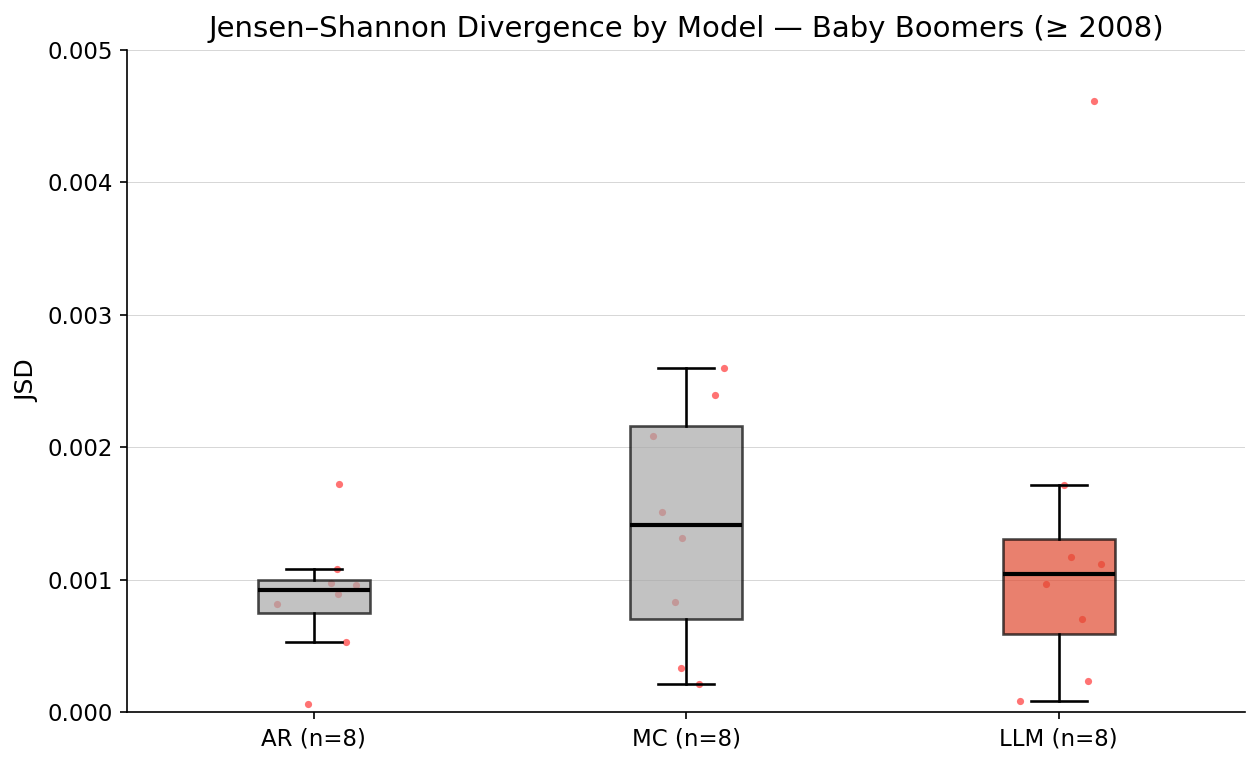

In [125]:
# Polished Matplotlib box plot for JSD (Baby Boomers), no seaborn

# --- 1) Filter & order
df = combined_g1[(combined_g1['generation'] == 'Baby Boomer') & (combined_g1['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Baby Boomers (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.005)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()


## Abortion, Group 2

In [164]:
df_cs_abo.shape, df_pl_abo.shape, df_cs_homosex.shape, df_pl_homosex.shape

((13351, 13), (12610, 12), (17576, 12), (13647, 11))

In [165]:
# Find p_cs and Nfrom
cs = df_cs_abo.copy()
# Map to 4 bins if numeric:
cs = cs[cs["abortion_att4"].isin(ABORT4)].copy()
cs["wt"] = cs.get("wtssps", pd.Series([1.0]*len(cs)))

GROUP_COLS = GROUP_COLS_2
for c in GROUP_COLS: cs[c] = cs[c].astype(str).str.strip()

def weighted_probs(vals, wts, cats=ABORT4):
    d = {c:0.0 for c in cats}
    for v,w in zip(vals,wts): d[v]+=float(w)
    vec = np.array([d[c] for c in ABORT4],dtype=float)
    s = vec.sum()
    return vec/s if s>0 else None

# p_cs[(g,y)] -> np.array[K]
p_cs_g2 = {}
effN_cs_g2 = {}  # effective N for weighting samples in Task B
YEARS_CS = list(range(2006, 2025, 2))  # 2006..2024 every 2 years
for y in YEARS_CS:
    sub = cs[cs["year"]==y]
    if sub.empty:
        continue
    for g_vals, df_g in sub.groupby(GROUP_COLS_2):
        p = weighted_probs(df_g["abortion_att4"].tolist(), df_g["wt"].tolist(), ABORT4)
        if p is None:
            continue
        p_cs_g2[(g_vals, y)] = p
        effN_cs_g2[(g_vals, y)] = float(df_g["wt"].sum())

# Build panel transitions C[(g,t,Δ)] from consecutive waves per yearid
# Build transitions per (g, t, Δ)
# C[(g,t,Δ)] -> KxK counts; Nfrom[(g,t,Δ)] -> row totals length K
from collections import defaultdict

def canon_index(cat):
    return ABORT2ID.get(cat, None)

C_g2 = defaultdict(lambda: np.zeros((K,K), dtype=float))
Nfrom_g2 = defaultdict(lambda: np.zeros((K,), dtype=float))

# Weight=1.0
df_pl_abo["w"] = 1.0

# Consecutive transitions per id
for (pid), df_id_g2 in df_pl_abo.groupby("yearid"):
    df_id_g2 = df_id_g2.sort_values("year")
    # collapse duplicates per year if any
    df_id_g2 = df_id_g2.drop_duplicates(subset=["year"], keep="last")
    years = df_id_g2["year"].values.tolist()
    atts  = df_id_g2["abortion_att4"].values.tolist()
    wgts  = df_id_g2["w"].values.astype(float).tolist()
    gens  = df_id_g2["generation"].values.tolist()
    gend  = df_id_g2["gender"].values.tolist()
    # race  = df_id_g2["race"].values.tolist()
    # edu = df_id_g2["edu_level"].values.tolist()

    # require consistent group labels across waves for this id (common in panels)
    if not (len(set(gens))==1 and len(set(gend))==1):
        # if you prefer, skip inconsistent cases
        continue

    g = (gens[0],gend[0])
    
    # Abortion (K=4)
    K = len(ABORT4)
    for i in range(len(years)-1):
        t, t1 = int(years[i]), int(years[i+1])
        Δ = t1 - t
        if Δ not in (2,4):  # we only have 2-yr and 4-yr gaps here
            continue
        ai = canon_index(atts[i])
        aj = canon_index(atts[i+1])
        if ai is None or aj is None:
            continue
        w = float(wgts[i])  # or min(wgts[i], wgts[i+1])
        C_g2[(g,t,Δ)][ai, aj] += w
        Nfrom_g2[(g,t,Δ)][ai] += w

In [166]:
def jsd(a, b, eps=1e-12):
    a = np.clip(np.asarray(a, float), eps, 1); a = a/a.sum()
    b = np.clip(np.asarray(b, float), eps, 1); b = b/b.sum()
    m = 0.5*(a+b)
    return 0.5*np.sum(a*np.log(a/m)) + 0.5*np.sum(b*np.log(b/m))

# Fit baselines
p_hat_AR_g2 = cs_ar_fit_and_forecast(p_cs_g2, l2=1.0, min_years=3)
# If you have C, Nfrom loaded:
p_hat_MC_g2 = panel_markov_forecast(p_cs_g2, C_g2, Nfrom_g2, alpha=0.25)

# If you already built bt (your LLM backtest DataFrame), we can assemble a comparison table:
rows = []
by_group = {}
for (g,y), p_obs in p_cs_g2.items():
    by_group.setdefault(g, []).append(y)

for g, ys in by_group.items():
    ys = sorted(ys)
    for i in range(1, len(ys)):
        y_prev, y = ys[i-1], ys[i]
        rec = {c:v for c,v in zip(GROUP_COLS_2, g)}
        rec.update({"year_t": y_prev, "year_t1": y})
        p_obs = p_cs_g2[(g, y)]
        if (g, y) in p_hat_AR_g2:
            rec["JSD_AR"] = float(jsd(p_hat_AR_g2[(g,y)], p_obs))
        if (g, y) in p_hat_MC_g2:
            rec["JSD_MC"] = float(jsd(p_hat_MC_g2[(g,y)], p_obs))
        rows.append(rec)

bench = pd.DataFrame(rows)
bench.head()


,generation,gender,year_t,year_t1,JSD_AR,JSD_MC
0,Baby Boomer,Female,2006,2008,0.000934,0.000270
1,Baby Boomer,Female,2008,2010,0.000721,0.002306
2,Baby Boomer,Female,2010,2012,0.000311,0.001621
3,Baby Boomer,Female,2012,2014,0.000064,0.007359
4,Baby Boomer,Female,2014,2016,0.000500,0.001613


In [167]:
# Load our predicted values (p-hat)
df_pred_g2 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_abortion_g2.csv")

# Convert year 2021 to 2020
df_pred_g2.loc[df_pred_g2['year'] == 2021, 'year'] = 2020
df_pred_g2.loc[df_pred_g2['year_prev'] == 2021, 'year_prev'] = 2020

# Create new columns, year_t and year_t1
df_pred_g2['year_t'] = df_pred_g2['year_prev']
df_pred_g2['year_t1'] = df_pred_g2['year']

# gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
# df_pred_g2['generation'] = df_pred_g2['generation'].map(gen_map)

df_pred_g2.head(2)

,generation,gender,year_prev,year,p_prev_strong_anti,p_prev_anti,p_prev_pro,p_prev_strong_pro,p_trans_strong_anti,p_trans_anti,...,p_obs_strong_anti,p_obs_anti,p_obs_pro,p_obs_strong_pro,JSD_hat_vs_obs,RMSE_hat_vs_obs,JSD_trans_vs_obs,JSD_margin_vs_obs,year_t,year_t1
0,Baby Boomer,Female,2006,2008,0.214584,0.279195,0.113099,0.393122,0.197374,0.269936,...,0.213560,0.262077,0.146479,0.377884,0.002417,0.032242,0.000779,0.010337,2006,2008
1,Baby Boomer,Female,2008,2010,0.213560,0.262077,0.146479,0.377884,0.199815,0.275847,...,0.245294,0.225467,0.148570,0.380669,0.002788,0.036969,0.002990,0.008861,2008,2010


In [177]:
df_pred_g2 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/forecasts_from_previous_year_abortion_g2.csv")

In [178]:
df_pred_g2['year_prev'].value_counts()

year_prev
2022    14
2016    12
2018    12
2006    10
2010    10
2014    10
2012     9
2008     9
Name: count, dtype: int64

In [168]:
# Observed vs. LLM plot
# Build p_hat from df_pred
Category = ABORT4

def get_group_cols(group=GROUP_COLS_2):
    return group

def list_groups_sorted_by_coverage(p_cs, min_years=3):
    counts = {}
    for (g, y) in p_cs.keys():
        counts.setdefault(g, set()).add(y)
    items = sorted(((g, len(ys)) for g, ys in counts.items()),
                   key=lambda x: x[1], reverse=True)
    return [g for g, n in items if n >= min_years]

def _extract_bt_series_for_group(bt, g, series="hat"):
    """
    bt: backtest DF with columns like p_hat_<cat>, p_margin_<cat>, p_trans_<cat>
    g: tuple of group values in get_group_cols() order
    series: 'hat', 'margin', or 'trans'
    Returns dict year -> np.array(K)
    """
    if bt is None:
        return {}
    # Filter to rows for this group
    mask = np.ones(len(bt), dtype=bool)
    for c, v in zip(get_group_cols(), g):
        mask &= (bt[c] == v)
    sub = bt.loc[mask].copy()
    if sub.empty:
        return {}

    # Predictions are for year_t1
    year_col = "year_t1"
    out = {}
    for _, row in sub.iterrows():
        vec = []
        for cat in Category:
            col = f"p_{series}_{cat}"
            if col not in sub.columns:
                # If you saved only ensemble 'hat', default others to None
                return {}
            vec.append(row[col])
        vec = np.asarray(vec, dtype=float)
        y = int(row[year_col])
        out[y] = vec
    return out

def build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",)):
    """
    Build tidy DF with columns: year, category, observed, ar, llm_hat, llm_margin, llm_trans (as available).
    """
    years = sorted(y for (gg, y) in p_cs.keys() if gg == g)
    # Collect T-LLM series
    t_series = {}
    for s in llm_series:
        t_series[s] = _extract_bt_series_for_group(bt, g, series=s)

    rows = []
    for y in years:
        p_obs = p_cs.get((g, y))
        p_ar  = p_hat_AR.get((g, y))
        p_mc  = p_hat_MC.get((g, y))
        for k, cat in enumerate(Category):
            rec = {
                "year": y,
                "category": cat,
                "observed": float(p_obs[k]) if p_obs is not None else np.nan,
                "ar": float(p_ar[k]) if p_ar is not None else np.nan,
                "mc": float(p_mc[k]) if p_mc is not None else np.nan
            }
            for s in llm_series:
                vecs = t_series.get(s, {})
                rec[f"llm_{s}"] = float(vecs[y][k]) if y in vecs else np.nan
            rows.append(rec)
    return pd.DataFrame(rows)

def plot_vs_observed_for_group_with_llm(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs LLM — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        #ax.plot(d["year"], d["ar"], marker="s", linestyle="--", label="AR")
        #ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle="--", label="MC")

        # Add LLM lines
        color_cycle_added = False
        for s in llm_series:
            ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle="-", color="#e14b31",
                    label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()



def plot_vs_observed_for_group_with_baselines(
    g, p_cs, p_hat_AR, p_hat_MC, bt=None, llm_series=("hat",), save_path=None
):
    """
    4-panel plot (one per category): Observed vs AR vs MC vs LLM.
    llm_series can be any subset of ('hat','margin','trans'), e.g. ('hat',) or ('hat','margin').
    """
    df = build_group_timeseries_with_llm(g, p_cs, p_hat_AR, p_hat_MC, bt, llm_series=llm_series)
    if df.empty:
        print("No data for that group.")
        return

    years = sorted(df["year"].unique())
    fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
    axes = axes.ravel()

    group_label = "; ".join(f"{c}={v}" for c, v in zip(get_group_cols(), g))
    fig.suptitle(f"Observed vs Baselines (AR, MC) — {group_label}", y=1.02, fontsize=12)

    for i, cat in enumerate(Category):
        ax = axes[i]
        d = df[df["category"] == cat].sort_values("year")

        ax.plot(d["year"], d["observed"], marker="o", linestyle="-", color="darkgrey", label="Observed")
        ax.plot(d["year"], d["ar"], marker="s", linestyle=":", color="orange", label="AR")
        ax.plot(d["year"], d["mc"], marker="s", color="green", linestyle=":", label="MC")

        # # Add LLM lines
        # color_cycle_added = False
        # for s in llm_series:
        #     ax.plot(d["year"], d[f"llm_{s}"], marker="^", linestyle=":",
        #             label=f"LLM {s}")

        ax.set_title(cat)
        ax.set_xticks(range(2006,2026,2))
        ax.grid(alpha=0.3)
        if i % 2 == 0:
            ax.set_ylabel("Proportion")
        if i // 2 == 1:
            ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    # deduplicate legend entries
    seen = set(); h2, l2 = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); h2.append(h); l2.append(l)
    fig.legend(h2, l2, loc="lower center", ncol=min(4, 2+len(llm_series)), bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show()

In [169]:
# Calculate weighted means and standard errors for G2
df_cs_abo.groupby(['generation', 'gender']).agg(
    wtssps_mean=('wtssps', 'mean'),
    wtssps_se=('wtssps', lambda x: np.std(x, ddof=1) / np.sqrt(len(x)))
).reset_index().sort_values('wtssps_se', ascending=False).head(10)

,generation,gender,wtssps_mean,wtssps_se
7,Generation Z,Other,1.247082,0.471096
6,Generation Z,Male,1.592685,0.111065
5,Generation Z,Female,1.393661,0.095487
4,Generation X,Other,0.752495,0.043245
9,Millennial,Male,1.261334,0.025228
12,Silent Generation,Male,1.015371,0.025051
8,Millennial,Female,1.039779,0.021664
3,Generation X,Male,1.041233,0.018505
11,Silent Generation,Female,0.825508,0.016949
2,Generation X,Female,0.927241,0.015863


In [170]:
df_pred_g2['generation'].value_counts()

generation
Baby Boomer          16
Generation X         16
Millennial           16
Silent Generation    16
Generation Z          7
Name: count, dtype: int64

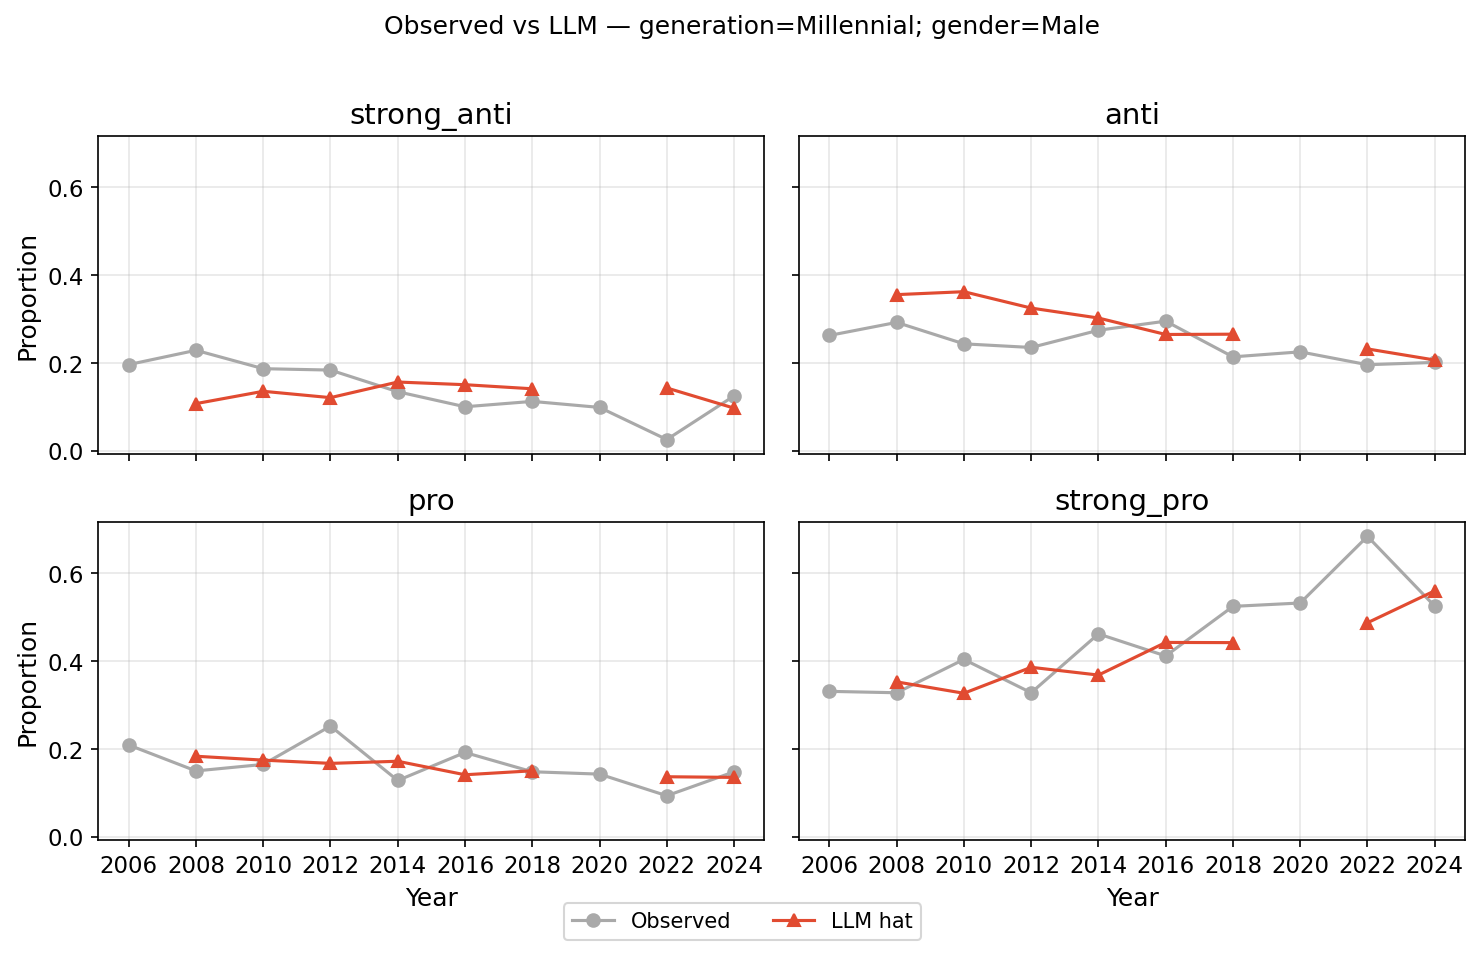

In [171]:
g = ('Millennial', "Male")
#g = ('Silent Generation', 'Male', 'Black', "Graduate Degree")
#g = ('Baby Boomer', 'Male', 'White', "Associate or Bachelor's Degree")
plot_vs_observed_for_group_with_llm(g, p_cs_g2, p_hat_AR_g2, p_hat_MC_g2, bt=df_pred_g2, llm_series=("hat",))

In [138]:
plot_vs_observed_for_group_with_baselines(g, p_cs_g2, p_hat_AR_g2, p_hat_MC_g2, bt=df_pred_g2, llm_series=("hat",))

No data for that group.


In [154]:
# Compare JSD
bt_abo_g2 = pd.read_csv("/Users/wooyongjung/Library/CloudStorage/GoogleDrive-woo.firstrunner@gmail.com/My Drive/LLM_POC_Study_2025_v2/p_trial_results/backtest_by_interval_abortion_g2.csv")

gen_map = {'B':'Baby Boomer', 'G':'Generation X', 'M':'Millennial', 'S':'Silent Generation'}
bt_abo_g2['generation'] = bt_abo_g2['generation'].map(gen_map)

bt_abo_g2.head()

,year_t,year_t1,generation,gender,JSD_hat,JSD_trans,JSD_margin,RMSE_hat
0,2008,2010,NaN,Female,0.002788,0.002990,0.008861,0.036969
1,2008,2010,NaN,Male,0.002468,0.004433,0.002318,0.034587
2,2008,2010,NaN,Female,0.000843,0.001331,0.002698,0.019245
3,2008,2010,NaN,Male,0.004160,0.003691,0.004672,0.037327
4,2008,2010,NaN,Female,0.004296,0.007309,0.002099,0.047760


In [158]:
# Convert bench to long format
bench_long = pd.melt(bench, id_vars=GROUP_COLS_2 + ['year_t', 'year_t1'], value_vars=['JSD_AR', 'JSD_MC'], var_name='model', value_name='jsd')
model_map = {'JSD_AR': 'AR', 'JSD_MC': 'MC'}
bench_long['model'] = bench_long['model'].map(model_map)

# Prepare the data for plotting
bt_abo_g2['model'] = 'LLM'
bt_abo_g2 = bt_abo_g2.rename(columns={'JSD_hat':'jsd'})
combined_g2 = pd.concat([bench_long, bt_abo_g2[['generation','gender','year_t','year_t1','model','jsd']]], ignore_index=True)
combined_g2.head()

,generation,gender,year_t,year_t1,model,jsd
0,Baby Boomer,Female,2006,2008,AR,0.000934
1,Baby Boomer,Female,2008,2010,AR,0.000721
2,Baby Boomer,Female,2010,2012,AR,0.000311
3,Baby Boomer,Female,2012,2014,AR,0.000064
4,Baby Boomer,Female,2014,2016,AR,0.000500


/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/775411759.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


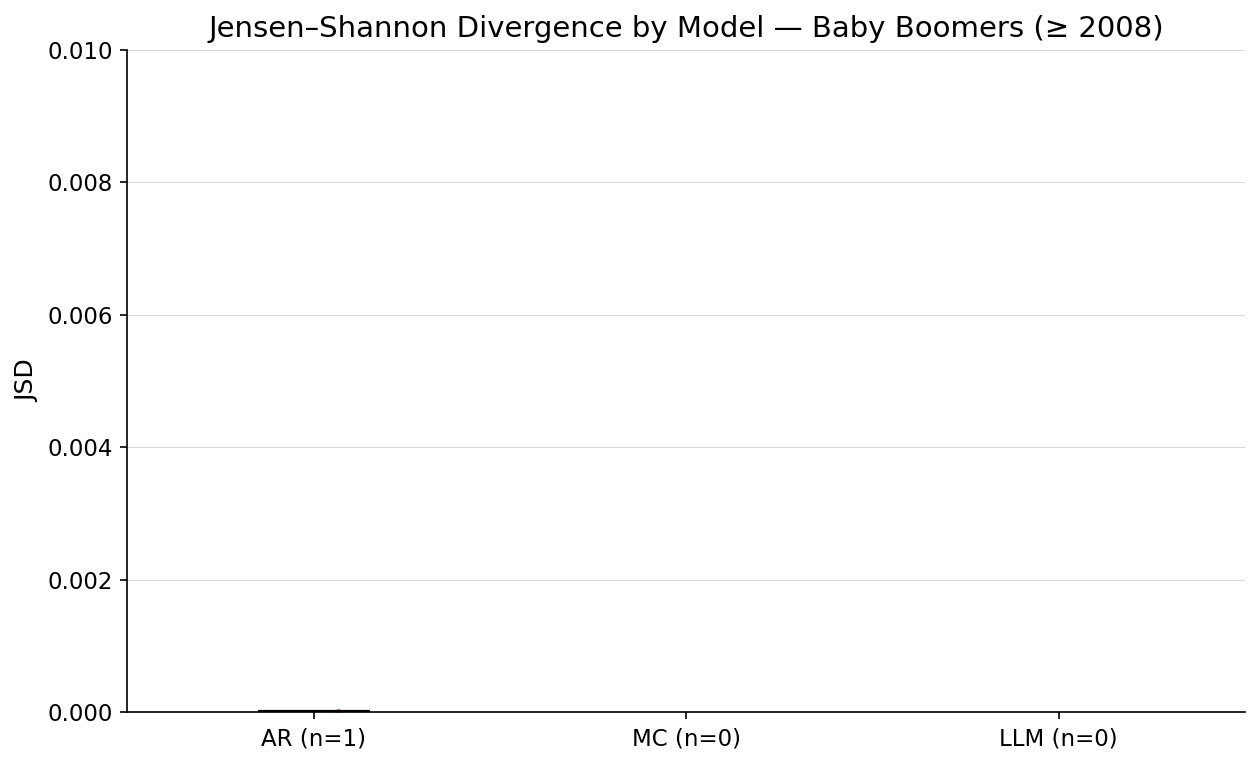

In [159]:
# Polished Matplotlib box plot for JSD (Millennials), no seaborn

# --- 1) Filter & order
df = combined_g2[(combined_g2['generation'] == 'Generation X') & ((combined_g2['gender'] == 'Other')) & (combined_g2['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Baby Boomers (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.01)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()

/var/folders/y6/z9h695vx2w3gbjh7z32h4j9m0000gn/T/ipykernel_65671/1178246954.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


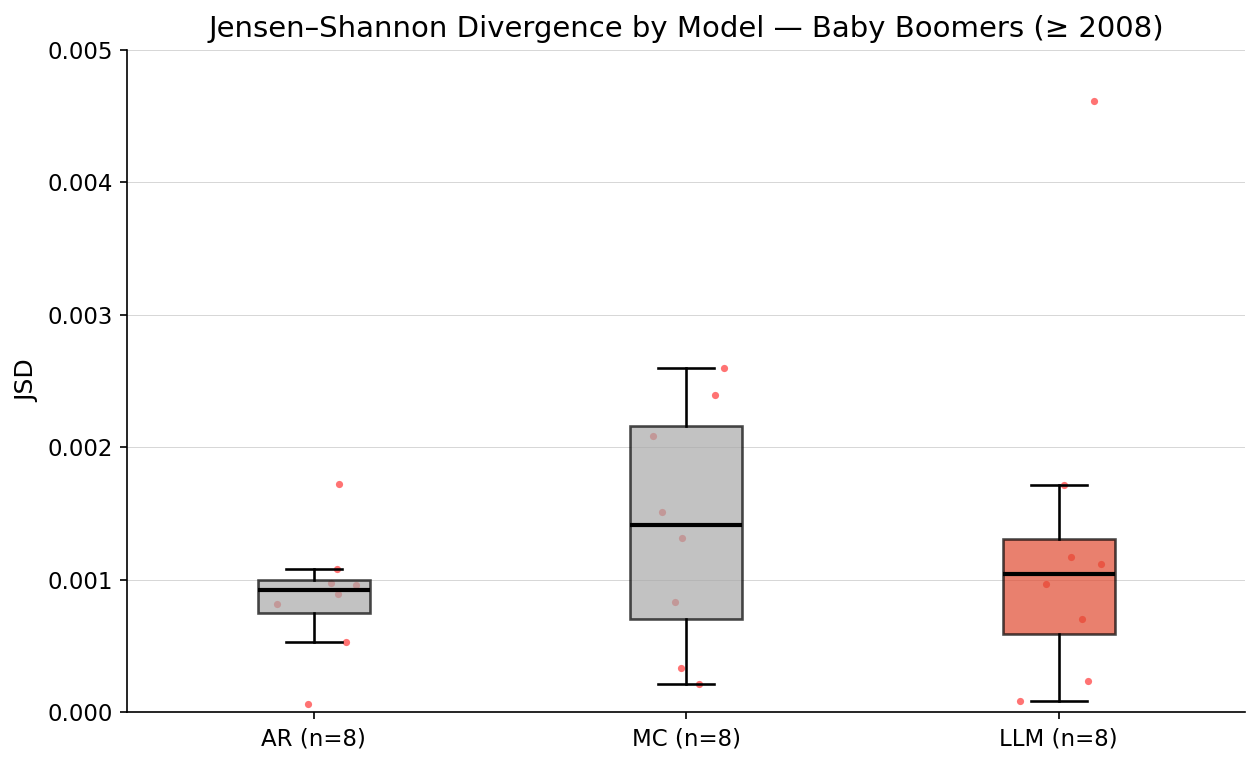

In [ ]:
# Polished Matplotlib box plot for JSD (Baby Boomers), no seaborn

# --- 1) Filter & order
df = combined_g2[(combined_g2['generation'] == 'Baby Boomer') & (combined_g2['year_t'] >= 2008)].copy()

# Ensure model order is consistent
model_order = ['AR', 'MC', 'LLM']
df = df[df['model'].isin(model_order)]
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

# Group data for plotting
groups = [df.loc[df['model'] == m, 'jsd'].dropna().values for m in model_order]
ns = [len(g) for g in groups]
labels = [f'{m} (n={n})' for m, n in zip(model_order, ns)]

# --- 2) Figure layout & typography
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})
fig, ax = plt.subplots(figsize=(8.5, 5.2))

# --- 3) Boxplot (clean look)
bp = ax.boxplot(
    groups,
    vert=True,
    patch_artist=True,   # enables filled boxes (uses default facecolors)
    labels=labels,
    showfliers=False,    # hide extreme fliers; reduces visual clutter
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.25),
    whiskerprops=dict(linewidth=1.25),
    capprops=dict(linewidth=1.25)
)

colors = ["darkgrey", "darkgrey", "#e14b31"]
# Apply colors to the box patches
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)   # optional transparency

# You can also recolor median lines, whiskers, caps, etc. if desired:
for median, color in zip(bp['medians'], colors):
    median.set_color("black")
    median.set_linewidth(2)


# Optionally lighten fill (keeps defaults if you prefer)
# for b in bp['boxes']:
#     b.set_alpha(0.6)

# --- 4) Add jittered points (optional but helpful to show distribution)
rng = np.random.default_rng(42)
x_positions = np.arange(1, len(groups) + 1)
for i, g in enumerate(groups, start=1):
    if len(g) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(g))
    ax.scatter(
        np.full_like(g, i, dtype=float) + jitter,
        g,
        s=12,
        alpha=0.55,
        linewidths=0.0,
        color = 'red'
    )

# --- 5) Titles, labels, limits, and polish
ax.set_title('Jensen–Shannon Divergence by Model — Baby Boomers (≥ 2008)')
ax.set_ylabel('JSD')

# Keep your original y-limit if you want a tight view; otherwise comment it out
ax.set_ylim(0, 0.005)

# Subtle grid only on y axis
ax.grid(axis='y', linestyle='-', linewidth=0.4, alpha=0.6)

# De-emphasize the frame
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
plt.show()
